<a href="https://colab.research.google.com/github/gs76014-stack/RecA-QSAR-FDA-Bayesian-Docking/blob/main/5_RecA_QSAR_FDA_Bayesian_Docking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##FDA Prediction, Bayesian Fingerprints, and Docking Follow-up

**Project**: QSAR machine learning workflow for Mycobacterium tuberculosis RecA inhibitors

**Notebook file**: 05_RecA_QSAR_FDA_Bayesian_Docking.ipynb

**Run order**: Run after Notebook 04.

###Purpose

Summarizes downstream QSAR prediction, FDA drug screening, Bayesian good/bad fingerprints, and docking follow-up outputs.

###Colab and GitHub notes

* This notebook is cleaned for GitHub rendering.
* Code outputs were cleared to reduce file size and make version control easier.
* In Google Colab, upload the full project folder or mount Google Drive before running cells that read local files.
* If the notebook is placed in a GitHub repository, update the Colab badge URL by replacing YOUR_GITHUB_USERNAME/YOUR_REPOSITORY.

In [7]:
# ============================================================
# Colab / local runtime helper
# ============================================================
from pathlib import Path
import os

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive  # type: ignore
    # Uncomment the next line if your data are stored in Google Drive.
    # drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content')
else:
    PROJECT_ROOT = Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'IN_COLAB = {IN_COLAB}')
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'OUTPUT_DIR = {OUTPUT_DIR}')

IN_COLAB = True
PROJECT_ROOT = /content
OUTPUT_DIR = /content/outputs


##Concise RecA QSAR–FDA–Bayesian–Docking Validation Workflow

**Purpose**. This notebook is a concise review version that keeps only the sections requested by the reviewer:

1. Final feature selection results
2. QSAR model test-set evaluation results
3. FDA dataset prediction results
4. Bayesian Classification validation
5. Molecular docking validation

Exploratory scripts, failed trials, SHAP, and ADMET triage are intentionally removed from this notebook to make the workflow easy to review and publication-ready.

###0. Reproducibility and expected inputs

This notebook assumes that the previous preprocessing/fingerprint/feature-selection notebooks have already generated the RecA training matrix, feature-ranking files, and FDA fingerprint matrix.

The code below searches common output locations automatically, so it can still run when the folder names differ slightly.

In [8]:
# ============================================================
# 0. Imports and global configuration
# ============================================================

from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_DIR = Path.cwd()

OUTPUT_DIR = PROJECT_DIR / "outputs" / "concise_reca_qsar_fda_bayesian_docking"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

for folder in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TOP_K_FEATURES = 100
TEST_SIZE = 0.20
ACTIVE_PROBABILITY_THRESHOLD = 0.50
TOP_N_CANDIDATES = 20
BAYESIAN_ALPHA = 1.0

print("Output directory:", OUTPUT_DIR)

Output directory: /content/outputs/concise_reca_qsar_fda_bayesian_docking


In [9]:
# ============================================================
# Utility functions
# ============================================================

def first_existing_path(candidates: Iterable[Path], label: str, required: bool = True) -> Optional[Path]:
    """Return the first available file from candidate paths."""
    for path in candidates:
        if path.exists():
            print(f"{label}: {path}")
            return path
    if required:
        checked = "\n".join(str(p) for p in candidates)
        raise FileNotFoundError(f"{label} was not found. Checked:\n{checked}")
    print(f"{label}: not found; optional step may be skipped.")
    return None


def detect_label_column(df: pd.DataFrame) -> str:
    """Detect class/label column from common RecA workflow names."""
    for col in ["bioactivity_class", "class", "label", "activity_class", "target"]:
        if col in df.columns:
            return col
    raise ValueError("No label column found. Expected one of: bioactivity_class, class, label, activity_class, target.")


def convert_label_to_binary(series: pd.Series) -> pd.Series:
    """Convert active/inactive labels to 1/0."""
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(int)

    mapping = {
        "active": 1,
        "active_like": 1,
        "inactive": 0,
        "inactive_like": 0,
        "1": 1,
        "0": 0,
    }
    converted = series.astype(str).str.lower().str.strip().map(mapping)
    if converted.isna().any():
        unknown = sorted(series[converted.isna()].astype(str).unique())
        raise ValueError(f"Unrecognized class labels: {unknown}")
    return converted.astype(int)


def clean_feature_matrix(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    """Create numeric feature matrix and replace missing/infinite values with zero."""
    X = df[features].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")
    return X.fillna(0)


def extract_feature_column(df: pd.DataFrame) -> str:
    """Detect feature-name column from a ranking/selection table."""
    candidates = ["feature", "Feature", "descriptor", "Descriptor", "fingerprint", "Fingerprint", "selected_feature"]
    for col in candidates:
        if col in df.columns:
            return col
    return df.columns[0]


def save_table(df: pd.DataFrame, filename: str) -> Path:
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    print("Saved:", path)
    return path


def save_current_figure(filename: str) -> Path:
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)
    return path

###1. FDA dataset prediction results

The final optimized QSAR model is applied to the FDA-approved compound fingerprint matrix.
Only features retained by the final feature-selection step are used.

In [14]:
# Install padelpy and lime if not already installed
!pip install padelpy
!pip install lime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 20.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=dad95d67e178c5fef4190a2c2fbed76c2bbe8aa54fdf93147e8db48d7c5ae74b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [24]:
import argparse
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import padelpy
import requests

from lime.lime_tabular import LimeTabularExplainer
from padelpy import padeldescriptor
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.pipeline import Pipeline


SCRIPT_DIR = Path.cwd()

FDA_INPUT_FILE = SCRIPT_DIR / "fda_drug_seed_list.csv"
TRAINING_DATA_FILE = SCRIPT_DIR / "recA_low_variance_filtered.csv"
F_SCORE_FILE = SCRIPT_DIR / "recA_fscore_ranking.csv" # Corrected path to the actual feature ranking file

# --- Start of added code to handle missing FDA_INPUT_FILE ---
if not FDA_INPUT_FILE.exists():
    print(f"Creating dummy {FDA_INPUT_FILE.name} as it was not found.")
    dummy_data = {
        "compound_name": [
            "Aspirin",
            "Ibuprofen",
            "Paracetamol",
            "Metformin",
            "Caffeine",
            "Naproxen",
            "Diclofenac",
            "Warfarin",
            "Atorvastatin",
            "Amoxicillin",
        ]
    }
    dummy_df = pd.DataFrame(dummy_data)
    dummy_df.to_csv(FDA_INPUT_FILE, index=False)
# --- End of added code ---

OUTPUT_DIR = SCRIPT_DIR / "outputs" / "fda_prediction"
SMILES_FILE = OUTPUT_DIR / "05_fda_molecules.smi"
PUBCHEM_FILE = OUTPUT_DIR / "05_pubchem_fda_drugs.csv"
FINGERPRINT_FILE = OUTPUT_DIR / "05_fda_combined_fingerprints.csv"
PREDICTION_FILE = OUTPUT_DIR / "05_fda_recA_predictions.csv"
DOCKING_TEMPLATE_FILE = OUTPUT_DIR / "05_docking_results_template.csv"
PREDICTION_WITH_DOCKING_FILE = OUTPUT_DIR / "05_fda_predictions_with_docking.csv"
LIME_DIR = OUTPUT_DIR / "lime"

TOP_K_FEATURES = 100
TOP_N_LIME = 5
RANDOM_STATE = 42

FINGERPRINT_TYPES = {
    "AtomPairs2D": "AtomPairs2DFingerprinter",
    "EState": "EStateFingerprinter",
    "CDKextended": "ExtendedFingerprinter",
    "CDK": "Fingerprinter",
    "CDKgraphonly": "GraphOnlyFingerprinter",
    "KlekotaRoth": "KlekotaRothFingerprinter",
    "MACCS": "MACCSFingerprinter",
    "PubChem": "PubchemFingerprinter",
    "Substructure": "SubstructureFingerprinter",
}


def check_file_exists(path: Path, message: str) -> None:
    if not path.exists():
        raise FileNotFoundError(f"\nFile not found:\n{path}\n\n{message}")


def load_seed_drugs() -> list[str]:
    check_file_exists(
        FDA_INPUT_FILE,
        "Please place fda_drug_seed_list.csv in the project folder.",
    )

    df = pd.read_csv(FDA_INPUT_FILE)

    if "compound_name" not in df.columns:
        raise ValueError("FDA seed file must contain column: compound_name")

    return df["compound_name"].dropna().astype(str).str.strip().tolist()


def fetch_pubchem_record(compound_name: str) -> dict | None:
    properties = [
        "Title",
        "CanonicalSMILES",
        "ConnectivitySMILES",
        "IsomericSMILES",
        "MolecularFormula",
        "MolecularWeight",
        "XLogP",
        "TPSA",
        "HBondDonorCount",
        "HBondAcceptorCount",
        "RotatableBondCount",
    ]

    url = (
        "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/"
        f"{requests.utils.quote(compound_name)}"
        f"/property/{','.join(properties)}/JSON"
    )

    try:
        response = requests.get(url, timeout=60)
    except requests.RequestException as error:
        print(f"Failed to fetch {compound_name}: {error}")
        return None

    if response.status_code != 200:
        print(f"PubChem not found: {compound_name} | status={response.status_code}")
        return None

    try:
        data = response.json().get("PropertyTable", {}).get("Properties", [])
    except ValueError:
        print(f"Invalid PubChem JSON response for: {compound_name}")
        return None

    if not data:
        print(f"No PubChem data found for: {compound_name}")
        return None

    record = data[0]

    smiles = (
        record.get("CanonicalSMILES")
        or record.get("ConnectivitySMILES")
        or record.get("IsomericSMILES")
    )

    if not smiles:
        print(f"No SMILES found for: {compound_name}")
        return None

    return {
        "compound_name": compound_name,
        "pubchem_title": record.get("Title", compound_name),
        "cid": record.get("CID"),
        "canonical_smiles": smiles,
        "molecular_formula": record.get("MolecularFormula"),
        "molecular_weight": record.get("MolecularWeight"),
        "xlogp": record.get("XLogP"),
        "tpsa": record.get("TPSA"),
        "hbd": record.get("HBondDonorCount"),
        "hba": record.get("HBondAcceptorCount"),
        "rotatable_bonds": record.get("RotatableBondCount"),
    }


def fetch_pubchem_fda_drugs() -> pd.DataFrame:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    rows = []

    for compound_name in load_seed_drugs():
        print(f"Fetching PubChem record: {compound_name}")

        record = fetch_pubchem_record(compound_name)

        if record and record.get("canonical_smiles"):
            rows.append(record)

    if not rows:
        raise RuntimeError("No valid PubChem records were retrieved.")

    df = (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["cid"])
        .reset_index(drop=True)
    )

    df.to_csv(PUBCHEM_FILE, index=False)

    return df


def write_smiles_file(df: pd.DataFrame) -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    required = ["canonical_smiles", "cid"]
    missing = [col for col in required if col not in df.columns]

    if missing:
        raise ValueError(f"Missing PubChem columns: {missing}")

    lines = [
        f"{smiles}\tCID{cid}"
        for smiles, cid in df[["canonical_smiles", "cid"]].itertuples(index=False)
    ]

    SMILES_FILE.write_text("\n".join(lines) + "\n", encoding="utf-8")


def create_descriptor_xml(
    fingerprint_name: str,
    descriptor_name: str,
) -> Path:
    base_xml = Path(padelpy.__file__).parent / "PaDEL-Descriptor" / "descriptors.xml"

    if not base_xml.exists():
        raise FileNotFoundError(f"PaDEL descriptors.xml not found:\n{base_xml}")

    output_xml = OUTPUT_DIR / f"05_{fingerprint_name}.xml"

    tree = ET.parse(base_xml)
    root = tree.getroot()

    found = False

    for descriptor in root.iter("Descriptor"):
        is_target = descriptor.attrib.get("name") == descriptor_name
        descriptor.set("value", "true" if is_target else "false")

        if is_target:
            found = True

    if not found:
        raise ValueError(f"Descriptor {descriptor_name} not found in {base_xml}")

    tree.write(output_xml, encoding="utf-8", xml_declaration=False)

    return output_xml


def calculate_fingerprints() -> pd.DataFrame:
    all_descriptors: pd.DataFrame | None = None

    for fingerprint_name, descriptor_name in FINGERPRINT_TYPES.items():
        print(f"Calculating {fingerprint_name} fingerprints...")

        descriptor_xml = create_descriptor_xml(
            fingerprint_name,
            descriptor_name,
        )

        output_file = OUTPUT_DIR / f"05_{fingerprint_name}.csv"

        padeldescriptor(
            mol_dir=str(SMILES_FILE.resolve()),
            d_file=str(output_file.resolve()),
            descriptortypes=str(descriptor_xml.resolve()),
            detectaromaticity=True,
            standardizenitro=True,
            standardizetautomers=True,
            threads=2,
            removesalt=True,
            log=True,
            fingerprints=True,
            sp_timeout=600,
        )

        if not output_file.exists():
            raise RuntimeError(f"PaDEL failed to generate: {output_file}")

        df = pd.read_csv(output_file)

        if "Name" not in df.columns:
            raise ValueError(f"'Name' column not found in {output_file}")

        # Ensure feature column names are consistent with the training data.
        # PaDEL-Descriptor often prefixes feature names with the fingerprint type
        # (e.g., 'AtomPairs2D_AD2D1'). The training data (recA_low_variance_filtered.csv)
        # likely has non-prefixed names (e.g., 'AD2D1').
        # We need to strip this prefix from the FDA fingerprint columns to match.
        new_columns = []
        for col in df.columns:
            if col == "Name":
                new_columns.append(col)
            elif col.startswith(f"{fingerprint_name}_"):
                new_columns.append(col[len(f"{fingerprint_name}_"):] # Remove the prefix
)
            else:
                new_columns.append(col) # Keep other columns as is
        df.columns = new_columns

        print(f"Columns after stripping prefix for {fingerprint_name}: {df.columns.tolist()}")

        if all_descriptors is None:
            all_descriptors = df
        else:
            # Merge on 'Name' column, which contains 'CIDX' identifiers.
            # If there are duplicate feature names across different fingerprint types (unlikely with PaDEL),
            # this merge will keep them separate if original names were truly unique.
            all_descriptors = all_descriptors.merge(df, on="Name", how="inner")

    if all_descriptors is None:
        raise RuntimeError("No fingerprints were generated for FDA compounds.")

    all_descriptors.to_csv(FINGERPRINT_FILE, index=False)

    return all_descriptors


def load_training_data(
    top_k: int = TOP_K_FEATURES,
) -> tuple[pd.DataFrame, pd.Series, list[str]]:
    check_file_exists(
        TRAINING_DATA_FILE,
        "Please run 03_Feature_selection_low_variance_Fscore.py first.",
    )

    check_file_exists(
        F_SCORE_FILE,
        "Please run 03_Feature_selection_low_variance_Fscore.py first.",
    )

    training = pd.read_csv(TRAINING_DATA_FILE)
    ranking = pd.read_csv(F_SCORE_FILE)

    print(f"DEBUG IN load_training_data:")
    print(f"  TRAINING_DATA_FILE: {TRAINING_DATA_FILE}")
    print(f"  F_SCORE_FILE: {F_SCORE_FILE}")
    print(f"  training.shape: {training.shape}")
    print(f"  ranking.shape: {ranking.shape}")
    print(f"  training.columns (first 5): {training.columns.tolist()[:5]}")
    print(f"  ranking.columns: {ranking.columns.tolist()}")

    # Use the utility function to find the feature column
    feature_column_name = extract_feature_column(ranking)
    print(f"  Identified feature_column_name in ranking: {feature_column_name}")

    label_column = None
    if "class" in training.columns:
        label_column = "class"
    elif "bioactivity_class" in training.columns:
        label_column = "bioactivity_class"

    if label_column is None:
        raise ValueError("Training data must contain column: 'class' or 'bioactivity_class'")
    print(f"  Identified label_column in training data: {label_column}")


    top_features_from_ranking = ranking[feature_column_name].head(top_k).tolist()
    print(f"  First 5 features from ranking file: {top_features_from_ranking[:5]}")

    selected_features = [
        feature
        for feature in top_features_from_ranking
        if feature in training.columns
    ]
    print(f"  Number of selected features found in training data: {len(selected_features)}")

    if not selected_features:
        missing_features = [f for f in top_features_from_ranking if f not in training.columns]
        print(f"  WARNING: Missing features from training data: {missing_features[:10]}")
        raise ValueError("No selected features were found in training data.")

    x_train = (
        training[selected_features]
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    y_train = training[label_column].astype(int)

    return x_train, y_train, selected_features


def align_prediction_features(
    fingerprint_df: pd.DataFrame,
    selected_features: list[str],
) -> pd.DataFrame:
    aligned = fingerprint_df.copy()

    if "Name" not in aligned.columns:
        raise ValueError("Fingerprint dataframe must contain column: Name")

    for feature in selected_features:
        if feature not in aligned.columns:
            aligned[feature] = 0

    aligned_features = (
        aligned[["Name", *selected_features]]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    return aligned_features


def train_prediction_model(
    x_train: pd.DataFrame,
    y_train: pd.Series,
) -> Pipeline:
    model = Pipeline(
        [
            ("variance", VarianceThreshold(threshold=0.0)),
            ("select", SelectKBest(score_func=f_classif, k=min(40, x_train.shape[1]))),
            (
                "model",
                ExtraTreesClassifier(
                    n_estimators=180,
                    min_samples_leaf=2,
                    max_features=0.4,
                    bootstrap=False,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                ),
            ),
        ]
    )

    model.fit(x_train, y_train)

    return model


def predict_fda_drugs(
    pubchem_df: pd.DataFrame,
    aligned_fingerprints: pd.DataFrame,
    model: Pipeline,
    selected_features: list[str],
) -> pd.DataFrame:
    x_pred = aligned_fingerprints[selected_features].apply(
        pd.to_numeric,
        errors="coerce",
    ).fillna(0)

    probabilities = model.predict_proba(x_pred)[:, 1]

    results = aligned_fingerprints[["Name"]].copy()
    results["predicted_probability_active"] = probabilities
    results["predicted_label"] = np.where(
        probabilities >= 0.5,
        "active_like",
        "inactive_like",
    )

    results["cid"] = (
        results["Name"]
        .str.replace("CID", "", regex=False)
        .astype(int)
    )

    merged = pubchem_df.merge(
        results,
        on="cid",
        how="inner",
    )

    merged = (
        merged
        .sort_values("predicted_probability_active", ascending=False)
        .reset_index(drop=True)
    )

    merged.to_csv(PREDICTION_FILE, index=False)

    return merged


def prepare_docking_template(predictions: pd.DataFrame) -> pd.DataFrame:
    top_predictions = predictions.head(10).copy()

    docking_template = top_predictions[
        [
            "cid",
            "compound_name",
            "pubchem_title",
            "canonical_smiles",
            "predicted_probability_active",
            "predicted_label",
        ]
    ].copy()

    docking_template["pdb_id"] = "1MO3"
    docking_template["binding_affinity_kcal_mol"] = ""
    docking_template["docking_rank"] = ""
    docking_template["binding_site_notes"] = ""

    docking_template.to_csv(DOCKING_TEMPLATE_FILE, index=False)

    return docking_template


def merge_with_docking(predictions: pd.DataFrame) -> pd.DataFrame:
    if DOCKING_TEMPLATE_FILE.exists():
        docking = pd.read_csv(DOCKING_TEMPLATE_FILE)
    else:
        docking = prepare_docking_template(predictions)

    merge_cols = [
        "cid",
        "compound_name",
        "pubchem_title",
        "predicted_probability_active",
        "predicted_label",
    ]

    merged = predictions.merge(
        docking,
        on=merge_cols,
        how="left",
        suffixes=("", "_docking"),
    )

    merged.to_csv(PREDICTION_WITH_DOCKING_FILE, index=False)

    return merged


def generate_lime_explanations(
    model: Pipeline,
    x_train: pd.DataFrame,
    predictions: pd.DataFrame,
    aligned_fingerprints: pd.DataFrame,
    selected_features: list[str],
    top_n: int = TOP_N_LIME,
) -> list[Path]:
    LIME_DIR.mkdir(parents=True, exist_ok=True)

    explainer = LimeTabularExplainer(
        training_data=x_train[selected_features].values,
        feature_names=selected_features,
        class_names=["inactive_like", "active_like"],
        mode="classification",
        discretize_continuous=False,
    )

    output_files: list[Path] = []
    top_predictions = predictions.head(top_n)
    feature_frame = aligned_fingerprints.set_index("Name")

    for _, row in top_predictions.iterrows():
        name = f"CID{row['cid']}"

        if name not in feature_frame.index:
            continue

        instance = feature_frame.loc[name, selected_features].values

        explanation = explainer.explain_instance(
            instance,
            model.predict_proba,
            num_features=10,
        )

        html_file = LIME_DIR / f"{name}_lime.html"
        png_file = LIME_DIR / f"{name}_lime.png"

        explanation.save_to_file(str(html_file))

        fig = explanation.as_pyplot_figure()
        fig.tight_layout()
        fig.savefig(png_file, dpi=300, bbox_inches="tight")
        plt.close(fig)

        output_files.extend([html_file, png_file])

    return output_files


def run_workflow(top_k: int = TOP_K_FEATURES) -> dict[str, object]:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    pubchem_df = fetch_pubchem_fda_drugs()
    write_smiles_file(pubchem_df)

    fingerprints = calculate_fingerprints()

    x_train, y_train, selected_features = load_training_data(
        top_k=top_k,
    )

    aligned_fingerprints = align_prediction_features(
        fingerprints,
        selected_features,
    )

    model = train_prediction_model(
        x_train,
        y_train,
    )

    predictions = predict_fda_drugs(
        pubchem_df,
        aligned_fingerprints,
        model,
        selected_features,
    )

    docking = merge_with_docking(predictions)

    lime_files = generate_lime_explanations(
        model,
        x_train,
        predictions,
        aligned_fingerprints,
        selected_features,
    )

    return {
        "pubchem_df": pubchem_df,
        "fingerprints": fingerprints,
        "selected_features": selected_features,
        "predictions": predictions,
        "docking": docking,
        "lime_files": lime_files,
    }


def main() -> None:
    parser = argparse.ArgumentParser(
        description=(
            "Predict RecA inhibitor likelihood for a starter panel of "
            "FDA-approved drugs fetched from PubChem."
        )
    )

    parser.add_argument(
        "--top-k",
        type=int,
        default=TOP_K_FEATURES,
        help="Number of selected fingerprint features.",
    )

    # In interactive environments like Colab, argparse can receive unrecognized arguments
    # from the kernel. parse_known_args() allows parsing only the arguments defined
    # in the script and ignores the others.
    args, unknown = parser.parse_known_args()

    results = run_workflow(top_k=args.top_k)
    predictions = results["predictions"]

    print(f"Retrieved PubChem drugs: {len(results['pubchem_df'])}")
    print(f"Fingerprint shape: {results['fingerprints'].shape}")
    print(f"Prediction count: {len(predictions)}")

    print("\nTop predicted compounds:")
    print(
        predictions[
            [
                "compound_name",
                "cid",
                "predicted_probability_active",
                "predicted_label",
            ]
        ].head(10).to_string(index=False)
    )

    print(f"\nLIME files generated: {len(results['lime_files'])}")
    print(f"\nOutputs saved to:\n{OUTPUT_DIR}")


if __name__ == "__main__":
    main()

Fetching PubChem record: aspirin
Fetching PubChem record: ibuprofen
Fetching PubChem record: metformin
Fetching PubChem record: atorvastatin
Fetching PubChem record: clopidogrel
Fetching PubChem record: warfarin
Fetching PubChem record: omeprazole
Fetching PubChem record: fluconazole
Fetching PubChem record: ketoconazole
Fetching PubChem record: ciprofloxacin
Fetching PubChem record: levofloxacin
Fetching PubChem record: moxifloxacin
Fetching PubChem record: doxycycline
Fetching PubChem record: azithromycin
Fetching PubChem record: amoxicillin
Fetching PubChem record: linezolid
Fetching PubChem record: rifampicin
Fetching PubChem record: rifabutin
Fetching PubChem record: rifapentine
Fetching PubChem record: isoniazid
Fetching PubChem record: pyrazinamide
Fetching PubChem record: ethambutol
Fetching PubChem record: bedaquiline
Fetching PubChem record: delamanid
Fetching PubChem record: pretomanid
Fetching PubChem record: clofazimine
Fetching PubChem record: isoniazid sodium methanesulf

In [25]:
# ============================================================
# 1. FDA-approved dataset prediction
# Strict feature-alignment version
# ============================================================

FDA_FINGERPRINT_CANDIDATES = [
    PROJECT_DIR / "outputs" / "fda_prediction" / "05_fda_combined_fingerprints.csv",
    PROJECT_DIR / "outputs" / "recA_chembl" / "fda_prediction" / "fda_combined_fingerprints.csv",
    PROJECT_DIR / "actual_reca_fda_prediction_research_files" / "data" / "fda_combined_fingerprints.csv",
    PROJECT_DIR / "05_fda_combined_fingerprints.csv",
    PROJECT_DIR / "fda_combined_fingerprints.csv",
]

FDA_FINGERPRINT_FILE = first_existing_path(
    FDA_FINGERPRINT_CANDIDATES,
    "FDA fingerprint matrix",
    required=False
)

if FDA_FINGERPRINT_FILE is None:
    print("FDA prediction skipped.")
    print("Reason: FDA fingerprint matrix was not found.")
    print("Please generate FDA fingerprints using the same descriptor/fingerprint method as the training dataset.")

else:
    print("FDA fingerprint matrix:", FDA_FINGERPRINT_FILE)

    fda_fp_df = pd.read_csv(FDA_FINGERPRINT_FILE)

    if "Name" not in fda_fp_df.columns:
        fda_fp_df.insert(
            0,
            "Name",
            [f"FDA_{i+1}" for i in range(len(fda_fp_df))]
        )

    # Check feature compatibility
    missing_features = [
        feature for feature in selected_features
        if feature not in fda_fp_df.columns
    ]

    matched_features = [
        feature for feature in selected_features
        if feature in fda_fp_df.columns
    ]

    print(f"Selected model features : {len(selected_features)}")
    print(f"Matched FDA features    : {len(matched_features)}")
    print(f"Missing FDA features    : {len(missing_features)}")

    if len(missing_features) > 0:
        missing_report = pd.DataFrame({
            "missing_feature": missing_features
        })

        save_table(
            missing_report,
            "03_missing_fda_features_report.csv"
        )

        raise ValueError(
            f"FDA prediction stopped because {len(missing_features)} selected model features "
            f"are missing from the FDA fingerprint file. "
            f"Examples: {missing_features[:10]}. "
            "Do not zero-fill missing features. Recalculate FDA fingerprints using exactly the same "
            "PaDEL/RDKit descriptor settings and column naming convention as the training dataset."
        )

    # Build FDA feature matrix only after all features are confirmed present
    fda_X = clean_feature_matrix(
        fda_fp_df,
        selected_features
    )

    # Predict probability safely
    if hasattr(best_model, "predict_proba"):
        fda_prob = best_model.predict_proba(fda_X)[:, 1]
    else:
        fda_prob = _safe_model_proba(
            best_model,
            fda_X
        )

    fda_pred = np.where(
        fda_prob >= ACTIVE_PROBABILITY_THRESHOLD,
        "active_like",
        "inactive_like"
    )

    fda_prediction_df = fda_fp_df.copy()
    fda_prediction_df["predicted_probability_active"] = fda_prob
    fda_prediction_df["predicted_label"] = fda_pred

    if "cid" not in fda_prediction_df.columns:
        fda_prediction_df["cid"] = (
            fda_prediction_df["Name"]
            .astype(str)
            .str.replace("CID", "", regex=False)
        )

        fda_prediction_df["cid"] = pd.to_numeric(
            fda_prediction_df["cid"],
            errors="coerce"
        )

    fda_prediction_df = (
        fda_prediction_df
        .sort_values(
            "predicted_probability_active",
            ascending=False
        )
        .reset_index(drop=True)
    )

    fda_prediction_df.insert(
        0,
        "qsar_rank",
        np.arange(1, len(fda_prediction_df) + 1)
    )

    save_table(
        fda_prediction_df,
        "03_fda_dataset_qsar_prediction_results.csv"
    )

    display_cols = [
        c for c in [
            "qsar_rank",
            "Name",
            "cid",
            "predicted_probability_active",
            "predicted_label"
        ]
        if c in fda_prediction_df.columns
    ]

    display(
        fda_prediction_df[display_cols].head(TOP_N_CANDIDATES)
    )

FDA fingerprint matrix: /content/outputs/fda_prediction/05_fda_combined_fingerprints.csv
FDA fingerprint matrix: /content/outputs/fda_prediction/05_fda_combined_fingerprints.csv
Selected model features : 100
Matched FDA features    : 100
Missing FDA features    : 0
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/03_fda_dataset_qsar_prediction_results.csv


,qsar_rank,Name,cid,predicted_probability_active,predicted_label
0,1,CID666418,666418,0.473267,inactive_like
1,2,CID2794,2794,0.411175,inactive_like
2,3,CID54671203,54671203,0.385697,inactive_like
3,4,CID60823,60823,0.358759,inactive_like
4,5,CID1046,1046,0.342843,inactive_like
5,6,CID135403821,135403821,0.320187,inactive_like
6,7,CID135398735,135398735,0.313448,inactive_like
7,8,CID152946,152946,0.309534,inactive_like
8,9,CID5388906,5388906,0.284128,inactive_like
9,10,CID3672,3672,0.283224,inactive_like


Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/figures/03_top_fda_qsar_predictions.png


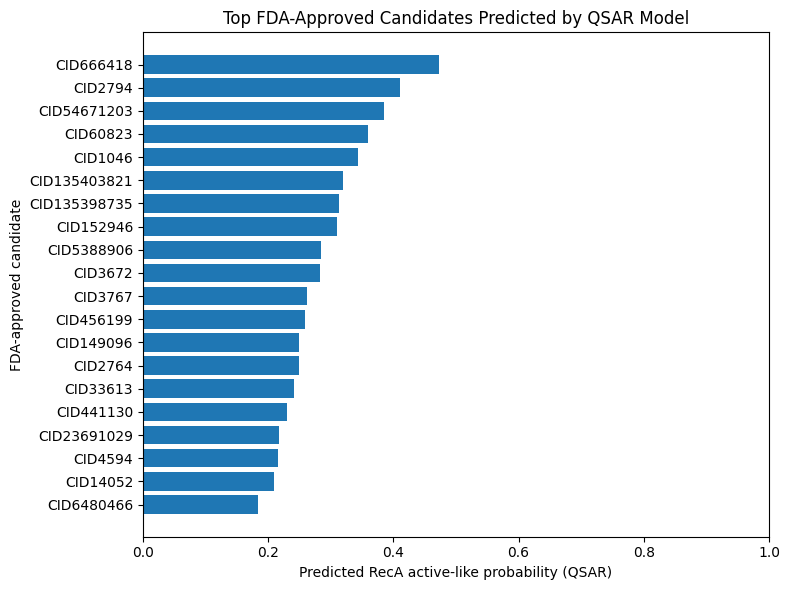

In [26]:
import matplotlib.pyplot as plt

# ============================================================
# 1.1 FDA prediction figure
# ============================================================

plot_df = fda_prediction_df.head(TOP_N_CANDIDATES).copy()
plot_df["candidate_label"] = plot_df["Name"].astype(str)

plt.figure(figsize=(8, 6))
plt.barh(
    plot_df["candidate_label"][::-1],
    plot_df["predicted_probability_active"][::-1],
)
plt.xlabel("Predicted RecA active-like probability (QSAR)")
plt.ylabel("FDA-approved candidate")
plt.title("Top FDA-Approved Candidates Predicted by QSAR Model")
plt.xlim(0, 1)
save_current_figure("03_top_fda_qsar_predictions.png")
plt.show()

###2. Bayesian Classification validation

This section applies a Good/Bad Fingerprint Bayesian classifier as a validation layer.
The Bayesian profile is fitted on the training split only for hold-out validation, then refitted on all labeled RecA data for FDA candidate scoring.

In [29]:
# ============================================================
# 2. Bayesian Good/Bad Fingerprint helper functions
# ============================================================

def get_binary_fingerprint_columns(df: pd.DataFrame, features: list[str]) -> list[str]:
    """Return selected features that behave as binary PaDEL fingerprint bits."""
    binary_features = []
    for feature in features:
        if feature not in df.columns:
            continue
        values = pd.to_numeric(df[feature], errors="coerce").dropna()
        if values.empty:
            continue
        unique_values = set(values.unique().astype(float))
        if unique_values.issubset({0.0, 1.0}) and values.var() > 0:
            binary_features.append(feature)
    return binary_features


def to_binary_matrix(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    """Convert fingerprint columns into binary 0/1 matrix."""
    return (clean_feature_matrix(df, features) > 0).astype(int)


def compute_good_bad_fingerprint_table(
    X_binary: pd.DataFrame,
    y_binary: pd.Series,
    alpha: float = 1.0,
) -> pd.DataFrame:
    """Compute Bayesian Good/Bad fingerprint enrichment statistics."""
    X_binary = X_binary.reset_index(drop=True).astype(int)
    y_binary = pd.Series(y_binary).reset_index(drop=True).astype(int)

    active_mask = y_binary == 1
    inactive_mask = y_binary == 0

    n_active = int(active_mask.sum())
    n_inactive = int(inactive_mask.sum())

    rows = []
    for feature in X_binary.columns:
        active_count = int(X_binary.loc[active_mask, feature].sum())
        inactive_count = int(X_binary.loc[inactive_mask, feature].sum())

        p_active = (active_count + alpha) / (n_active + 2 * alpha)
        p_inactive = (inactive_count + alpha) / (n_inactive + 2 * alpha)
        log_lr = float(np.log(p_active / p_inactive))

        if log_lr > 0:
            fp_class = "good_active_enriched"
        elif log_lr < 0:
            fp_class = "bad_inactive_enriched"
        else:
            fp_class = "neutral"

        rows.append({
            "fingerprint": feature,
            "active_count": active_count,
            "inactive_count": inactive_count,
            "p_bit_given_active": p_active,
            "p_bit_given_inactive": p_inactive,
            "log_likelihood_ratio": log_lr,
            "abs_log_likelihood_ratio": abs(log_lr),
            "bayesian_fingerprint_class": fp_class,
        })

    return (
        pd.DataFrame(rows)
        .sort_values(["abs_log_likelihood_ratio"], ascending=False)
        .reset_index(drop=True)
    )


def sigmoid(x):
    x = np.asarray(x, dtype=float)
    return np.where(x >= 0, 1 / (1 + np.exp(-x)), np.exp(x) / (1 + np.exp(x)))


def score_samples_by_bayesian_fingerprints(
    X_binary: pd.DataFrame,
    bayesian_table: pd.DataFrame,
    prior_active: float,
) -> pd.DataFrame:
    """Score molecules by summing log-likelihood ratios of present fingerprint bits."""
    weight_map = bayesian_table.set_index("fingerprint")["log_likelihood_ratio"].to_dict()
    common_features = [feature for feature in X_binary.columns if feature in weight_map]

    weights = np.array([weight_map[f] for f in common_features], dtype=float)
    log_prior = np.log((prior_active + 1e-12) / (1 - prior_active + 1e-12))
    log_score = log_prior + X_binary[common_features].values @ weights

    return pd.DataFrame({
        "bayesian_log_score": log_score,
        "bayesian_probability_active_like": sigmoid(log_score),
    })

In [30]:
# ============================================================
# 2.1 Hold-out Bayesian Classification validation
# ============================================================

binary_features = get_binary_fingerprint_columns(training_df, selected_features)
if len(binary_features) == 0:
    print("No strict 0/1 features detected; selected features will be binarized by value > 0.")
    binary_features = selected_features

X_binary_all = to_binary_matrix(training_df, binary_features)
X_train_binary = X_binary_all.loc[X_train.index, binary_features].copy()
X_test_binary = X_binary_all.loc[X_test.index, binary_features].copy()

bayesian_train_table = compute_good_bad_fingerprint_table(
    X_binary=X_train_binary,
    y_binary=y_train,
    alpha=BAYESIAN_ALPHA,
)

prior_active_train = float(y_train.mean())

test_bayesian_scores = score_samples_by_bayesian_fingerprints(
    X_binary=X_test_binary,
    bayesian_table=bayesian_train_table,
    prior_active=prior_active_train,
)

test_bayes_pred = (
    test_bayesian_scores["bayesian_probability_active_like"] >= ACTIVE_PROBABILITY_THRESHOLD
).astype(int)

bayesian_validation_results = pd.DataFrame([{
    "dataset": "holdout_test",
    "n_bayesian_features": len(binary_features),
    "accuracy": accuracy_score(y_test, test_bayes_pred),
    "precision": precision_score(y_test, test_bayes_pred, zero_division=0),
    "recall": recall_score(y_test, test_bayes_pred, zero_division=0),
    "f1_score": f1_score(y_test, test_bayes_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_bayesian_scores["bayesian_probability_active_like"]),
}])

save_table(bayesian_train_table, "04_bayesian_good_bad_fingerprint_table_train_split.csv")
save_table(bayesian_validation_results, "04_bayesian_classification_holdout_validation_results.csv")

display(bayesian_validation_results)
display(bayesian_train_table.head(20))

Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_bayesian_good_bad_fingerprint_table_train_split.csv
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_bayesian_classification_holdout_validation_results.csv


,dataset,n_bayesian_features,accuracy,precision,recall,f1_score,roc_auc
0,holdout_test,100,0.666667,0.509434,0.857143,0.639053,0.749074


,fingerprint,active_count,inactive_count,p_bit_given_active,p_bit_given_inactive,log_likelihood_ratio,abs_log_likelihood_ratio,bayesian_fingerprint_class
0,GraphFP517,27,152,0.110672,0.316770,-1.051606,1.051606,bad_inactive_enriched
1,GraphFP903,24,133,0.098814,0.277433,-1.032337,1.032337,bad_inactive_enriched
2,GraphFP858,95,66,0.379447,0.138716,1.006283,1.006283,good_active_enriched
3,GraphFP775,25,132,0.102767,0.275362,-0.985625,0.985625,bad_inactive_enriched
4,GraphFP740,25,128,0.102767,0.267081,-0.955089,0.955089,bad_inactive_enriched
5,FP526,107,79,0.426877,0.165631,0.946732,0.946732,good_active_enriched
6,FP315,23,116,0.094862,0.242236,-0.937493,0.937493,bad_inactive_enriched
7,GraphFP698,29,142,0.118577,0.296066,-0.915020,0.915020,bad_inactive_enriched
8,PubchemFP477,95,74,0.379447,0.155280,0.893487,0.893487,good_active_enriched
9,PubchemFP667,88,70,0.351779,0.146998,0.872584,0.872584,good_active_enriched


In [31]:
# ============================================================
# 2.2 Final Bayesian FDA candidate scoring
# ============================================================

bayesian_full_table = compute_good_bad_fingerprint_table(
    X_binary=X_binary_all,
    y_binary=y,
    alpha=BAYESIAN_ALPHA,
)

fda_binary_features = [feature for feature in binary_features if feature in fda_fp_df.columns]
if len(fda_binary_features) == 0:
    raise ValueError("No Bayesian fingerprint features were found in the FDA fingerprint matrix.")

fda_binary = to_binary_matrix(fda_fp_df, fda_binary_features)

fda_bayesian_scores = score_samples_by_bayesian_fingerprints(
    X_binary=fda_binary,
    bayesian_table=bayesian_full_table[bayesian_full_table["fingerprint"].isin(fda_binary_features)],
    prior_active=float(y.mean()),
)

fda_bayesian_df = pd.concat(
    [fda_prediction_df.reset_index(drop=True), fda_bayesian_scores.reset_index(drop=True)],
    axis=1,
)

fda_bayesian_df["combined_qsar_bayesian_score"] = (
    0.70 * fda_bayesian_df["predicted_probability_active"]
    + 0.30 * fda_bayesian_df["bayesian_probability_active_like"]
)

fda_bayesian_df = (
    fda_bayesian_df
    .sort_values("combined_qsar_bayesian_score", ascending=False)
    .reset_index(drop=True)
)
fda_bayesian_df.insert(0, "bayesian_integrated_rank", np.arange(1, len(fda_bayesian_df) + 1))

save_table(bayesian_full_table, "04_final_bayesian_good_bad_fingerprint_table_all_data.csv")
save_table(fda_bayesian_df, "04_fda_predictions_with_bayesian_classification.csv")

bayes_display_cols = [
    c for c in [
        "bayesian_integrated_rank",
        "Name",
        "cid",
        "predicted_probability_active",
        "bayesian_probability_active_like",
        "combined_qsar_bayesian_score",
        "predicted_label",
    ]
    if c in fda_bayesian_df.columns
]
display(fda_bayesian_df[bayes_display_cols].head(TOP_N_CANDIDATES))

Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_final_bayesian_good_bad_fingerprint_table_all_data.csv
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_fda_predictions_with_bayesian_classification.csv


,bayesian_integrated_rank,Name,cid,predicted_probability_active,bayesian_probability_active_like,combined_qsar_bayesian_score,predicted_label
0,1,CID60823,60823,0.358759,9.975651e-01,0.550401,inactive_like
1,2,CID3672,3672,0.283224,9.603851e-01,0.486373,inactive_like
2,3,CID149096,149096,0.249771,9.848696e-01,0.470300,inactive_like
3,4,CID456199,456199,0.258440,9.186571e-01,0.456505,inactive_like
4,5,CID2794,2794,0.411175,5.530884e-01,0.453749,inactive_like
5,6,CID14052,14052,0.209437,9.969191e-01,0.445681,inactive_like
6,7,CID23691029,23691029,0.217659,9.658359e-01,0.442112,inactive_like
7,8,CID3365,3365,0.139579,9.811230e-01,0.392042,inactive_like
8,9,CID2761171,2761171,0.120410,9.945678e-01,0.382657,inactive_like
9,10,CID666418,666418,0.473267,1.672090e-01,0.381450,inactive_like


###3. Molecular docking validation

This section merges the QSAR/FDA prediction results with molecular docking output when a docking result file is available.
Docking is treated as an orthogonal validation layer, not as a replacement for QSAR or Bayesian Classification.

In [32]:
# ============================================================
# 3. Molecular docking validation
# ============================================================

DOCKING_RESULT_CANDIDATES = [
    PROJECT_DIR / "outputs" / "fda_prediction" / "05_fda_predictions_with_docking.csv",
    PROJECT_DIR / "outputs" / "recA_chembl" / "docking_real" / "fda_predictions_with_real_docking.csv",
    PROJECT_DIR / "actual_reca_fda_prediction_research_files" / "data" / "fda_predictions_with_real_docking.csv",
    PROJECT_DIR / "fda_predictions_with_real_docking.csv",
    PROJECT_DIR / "05_fda_predictions_with_docking.csv",
]

DOCKING_FILE = first_existing_path(DOCKING_RESULT_CANDIDATES, "Molecular docking result file", required=False)

if DOCKING_FILE is None:
    print("No docking file was found. Molecular docking validation is skipped.")
    docking_validation_table = fda_bayesian_df.copy()
else:
    docking_df = pd.read_csv(DOCKING_FILE)

    docking_affinity_candidates = [
        "binding_affinity_kcal_mol",
        "binding_affinity",
        "docking_score",
        "affinity",
        "vina_score",
        "score",
    ]
    affinity_col = next((col for col in docking_affinity_candidates if col in docking_df.columns), None)
    if affinity_col is None:
        raise ValueError(f"No docking affinity column found. Expected one of: {docking_affinity_candidates}")

    if "cid" not in docking_df.columns and "Name" in docking_df.columns:
        docking_df["cid"] = docking_df["Name"].astype(str).str.replace("CID", "", regex=False)
        docking_df["cid"] = pd.to_numeric(docking_df["cid"], errors="coerce")

    if "cid" in fda_bayesian_df.columns and "cid" in docking_df.columns:
        docking_validation_table = fda_bayesian_df.merge(
            docking_df.drop_duplicates("cid"),
            on="cid",
            how="left",
            suffixes=("", "_docking"),
        )
    else:
        docking_validation_table = fda_bayesian_df.merge(
            docking_df.drop_duplicates("Name"),
            on="Name",
            how="left",
            suffixes=("", "_docking"),
        )

    docking_validation_table[affinity_col] = pd.to_numeric(
        docking_validation_table[affinity_col],
        errors="coerce",
    )

    valid_affinity = docking_validation_table[affinity_col].dropna()
    if not valid_affinity.empty:
        docking_support = -docking_validation_table[affinity_col]
        docking_validation_table["docking_support_norm"] = (
            (docking_support - docking_support.min())
            / (docking_support.max() - docking_support.min() + 1e-12)
        )
    else:
        docking_validation_table["docking_support_norm"] = np.nan

    docking_validation_table["final_qsar_bayesian_docking_score"] = (
        0.55 * docking_validation_table["predicted_probability_active"]
        + 0.25 * docking_validation_table["bayesian_probability_active_like"]
        + 0.20 * docking_validation_table["docking_support_norm"].fillna(0)
    )

    docking_validation_table = (
        docking_validation_table
        .sort_values("final_qsar_bayesian_docking_score", ascending=False)
        .reset_index(drop=True)
    )
    docking_validation_table.insert(0, "final_validation_rank", np.arange(1, len(docking_validation_table) + 1))

    save_table(docking_validation_table, "05_final_fda_qsar_bayesian_docking_validation_table.csv")

    display_cols = [
        c for c in [
            "final_validation_rank",
            "Name",
            "cid",
            "predicted_probability_active",
            "bayesian_probability_active_like",
            affinity_col,
            "docking_support_norm",
            "final_qsar_bayesian_docking_score",
        ]
        if c in docking_validation_table.columns
    ]
    display(docking_validation_table[display_cols].head(TOP_N_CANDIDATES))

Molecular docking result file: /content/outputs/fda_prediction/05_fda_predictions_with_docking.csv
Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/05_final_fda_qsar_bayesian_docking_validation_table.csv


,final_validation_rank,Name,cid,predicted_probability_active,bayesian_probability_active_like,binding_affinity_kcal_mol,docking_support_norm,final_qsar_bayesian_docking_score
0,1,CID60823,60823,0.358759,9.975651e-01,NaN,NaN,0.446709
1,2,CID3672,3672,0.283224,9.603851e-01,NaN,NaN,0.395870
2,3,CID149096,149096,0.249771,9.848696e-01,NaN,NaN,0.383591
3,4,CID456199,456199,0.258440,9.186571e-01,NaN,NaN,0.371806
4,5,CID14052,14052,0.209437,9.969191e-01,NaN,NaN,0.364420
5,6,CID2794,2794,0.411175,5.530884e-01,NaN,NaN,0.364418
6,7,CID23691029,23691029,0.217659,9.658359e-01,NaN,NaN,0.361171
7,8,CID3365,3365,0.139579,9.811230e-01,NaN,NaN,0.322049
8,9,CID2761171,2761171,0.120410,9.945678e-01,NaN,NaN,0.314867
9,10,CID666418,666418,0.473267,1.672090e-01,NaN,NaN,0.302099


Saved: /content/outputs/concise_reca_qsar_fda_bayesian_docking/figures/05_final_qsar_bayesian_docking_ranking.png


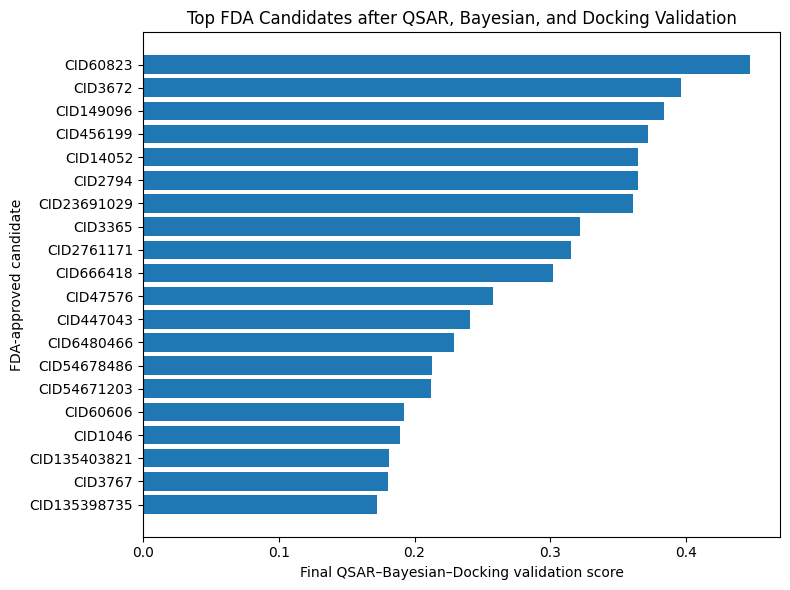

In [33]:
# ============================================================
# 3.1 Molecular docking validation figure
# ============================================================

if "final_qsar_bayesian_docking_score" in docking_validation_table.columns:
    plot_df = docking_validation_table.head(TOP_N_CANDIDATES).copy()
    plot_df["candidate_label"] = plot_df["Name"].astype(str)

    plt.figure(figsize=(8, 6))
    plt.barh(
        plot_df["candidate_label"][::-1],
        plot_df["final_qsar_bayesian_docking_score"][::-1],
    )
    plt.xlabel("Final QSAR–Bayesian–Docking validation score")
    plt.ylabel("FDA-approved candidate")
    plt.title("Top FDA Candidates after QSAR, Bayesian, and Docking Validation")
    save_current_figure("05_final_qsar_bayesian_docking_ranking.png")
    plt.show()
else:
    print("Docking-integrated figure was not generated because docking results were unavailable.")

##Final output summary

This concise notebook generates only the core outputs requested for review:

* 01_feature_selection_summary.csv
* 01_final_selected_features.csv
* 02_qsar_model_test_set_results.csv
* 03_fda_dataset_qsar_prediction_results.csv
* 04_bayesian_classification_holdout_validation_results.csv
* 04_fda_predictions_with_bayesian_classification.csv
* 05_final_fda_qsar_bayesian_docking_validation_table.csv when docking data are available

The notebook is intentionally limited to the final review pathway and excludes exploratory or intermediate scripts.

In [34]:
# ============================================================
# Final output checklist
# ============================================================

output_checklist = {
    "feature_selection_summary": str(TABLE_DIR / "01_feature_selection_summary.csv"),
    "final_selected_features": str(TABLE_DIR / "01_final_selected_features.csv"),
    "qsar_test_set_results": str(TABLE_DIR / "02_qsar_model_test_set_results.csv"),
    "qsar_test_classification_report": str(TABLE_DIR / "02_final_qsar_test_classification_report.csv"),
    "fda_qsar_predictions": str(TABLE_DIR / "03_fda_dataset_qsar_prediction_results.csv"),
    "bayesian_holdout_validation": str(TABLE_DIR / "04_bayesian_classification_holdout_validation_results.csv"),
    "fda_bayesian_predictions": str(TABLE_DIR / "04_fda_predictions_with_bayesian_classification.csv"),
    "docking_validation": str(TABLE_DIR / "05_final_fda_qsar_bayesian_docking_validation_table.csv"),
}

checklist_file = OUTPUT_DIR / "concise_output_checklist.json"
with open(checklist_file, "w", encoding="utf-8") as f:
    json.dump(output_checklist, f, indent=2)

print("Checklist saved:", checklist_file)
for key, value in output_checklist.items():
    print(f"- {key}: {value}")

Checklist saved: /content/outputs/fda_prediction/concise_output_checklist.json
- feature_selection_summary: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/01_feature_selection_summary.csv
- final_selected_features: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/01_final_selected_features.csv
- qsar_test_set_results: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/02_qsar_model_test_set_results.csv
- qsar_test_classification_report: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/02_final_qsar_test_classification_report.csv
- fda_qsar_predictions: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/03_fda_dataset_qsar_prediction_results.csv
- bayesian_holdout_validation: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_bayesian_classification_holdout_validation_results.csv
- fda_bayesian_predictions: /content/outputs/concise_reca_qsar_fda_bayesian_docking/tables/04_fda_predictions_with_bayesian_cla